 **16. MEDICAL INSURANCE COST ANALYSIS & PREDICTION SYSTEM
COMPLETE FINAL GOOGLE COLAB PROJECT**

**OBJECTIVE 1 : IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
import warnings
warnings.filterwarnings('ignore')
print("Libraries Imported Successfully")

Libraries Imported Successfully


**OBJECTIVE 2 : LOAD DATASET**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/insurance.csv')
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


**DISPLAY DATASET**

In [ ]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


**DATASET INFORMATION**

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


**DATASET SHAPE**

In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1338
Columns : 7


**COLUMN NAMES**

In [ ]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


**OBJECTIVE 3 : DATA CLEANING & PREPROCESSING**

**MISSING VALUES**

In [ ]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


**CHECK DUPLICATES**

In [ ]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 1


**REMOVE DUPLICATES**

In [ ]:
df = df.drop_duplicates()
print("Duplicates Removed Successfully")

Duplicates Removed Successfully


**CHECK DATA TYPES**

In [ ]:
print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


**ENCODE CATEGORICAL VARIABLES**

In [ ]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])
print("Encoding Completed")

Encoding Completed


**DISPLAY CLEANED DATASET**

In [ ]:
print(df.head())

   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


**OBJECTIVE 4 : DESCRIPTIVE STATISTICS**

In [ ]:
print(df.describe())

               age          sex          bmi     children       smoker  \
count  1337.000000  1337.000000  1337.000000  1337.000000  1337.000000   
mean     39.222139     0.504862    30.663452     1.095737     0.204936   
std      14.044333     0.500163     6.100468     1.205571     0.403806   
min      18.000000     0.000000    15.960000     0.000000     0.000000   
25%      27.000000     0.000000    26.290000     0.000000     0.000000   
50%      39.000000     1.000000    30.400000     1.000000     0.000000   
75%      51.000000     1.000000    34.700000     2.000000     0.000000   
max      64.000000     1.000000    53.130000     5.000000     1.000000   

            region       charges  
count  1337.000000   1337.000000  
mean      1.516081  13279.121487  
std       1.105208  12110.359656  
min       0.000000   1121.873900  
25%       1.000000   4746.344000  
50%       2.000000   9386.161300  
75%       2.000000  16657.717450  
max       3.000000  63770.428010  


**AVERAGE VALUES**

In [ ]:
print("Average Age :", df['age'].mean())
print("Average BMI :", df['bmi'].mean())
print("Average Children :", df['children'].mean())
print("Average Charges :", df['charges'].mean())

Average Age : 39.222139117427076
Average BMI : 30.66345175766642
Average Children : 1.0957367240089753
Average Charges : 13279.121486655948


**OBJECTIVE 5 : INSURANCE COST ANALYSIS**

In [ ]:
print(df.groupby('smoker')['charges'].mean())
print(df.groupby('sex')['charges'].mean())

smoker
0     8440.660307
1    32050.231832
Name: charges, dtype: float64
sex
0    12569.578844
1    13974.998864
Name: charges, dtype: float64


**BMI CATEGORY CREATION**

In [ ]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'
df['BMI_Category'] = df['bmi'].apply(bmi_category)
print(df.head())

   age  sex     bmi  children  smoker  region      charges BMI_Category
0   19    0  27.900         0       1       3  16884.92400   Overweight
1   18    1  33.770         1       0       2   1725.55230        Obese
2   28    1  33.000         3       0       2   4449.46200        Obese
3   33    1  22.705         0       0       1  21984.47061       Normal
4   32    1  28.880         0       0       1   3866.85520   Overweight


**BMI CATEGORY ANALYSIS**

In [ ]:
print(df.groupby('BMI_Category')['charges'].mean())

BMI_Category
Normal         10409.337709
Obese          15572.041945
Overweight     10987.509891
Underweight     8852.200585
Name: charges, dtype: float64


**AGE GROUP CREATION**

In [ ]:
bins = [18, 30, 45, 60, 100]
labels = ['Young', 'Adult', 'Middle Age', 'Senior']
df['Age_Group'] = pd.cut(df['age'], bins=bins, labels=labels)
print(df.head())

   age  sex     bmi  children  smoker  region      charges BMI_Category  \
0   19    0  27.900         0       1       3  16884.92400   Overweight   
1   18    1  33.770         1       0       2   1725.55230        Obese   
2   28    1  33.000         3       0       2   4449.46200        Obese   
3   33    1  22.705         0       0       1  21984.47061       Normal   
4   32    1  28.880         0       0       1   3866.85520   Overweight   

  Age_Group  
0     Young  
1       NaN  
2     Young  
3     Adult  
4     Adult  


**AGE GROUP ANALYSIS**

In [ ]:
print(df.groupby('Age_Group')['charges'].mean())

Age_Group
Young          9844.718012
Adult         12647.455654
Middle Age    16340.993846
Senior        21063.163398
Name: charges, dtype: float64


**OBJECTIVE 6 : GROUP BASED ANALYSIS**

In [ ]:
print(df.groupby('region')['charges'].mean())
print(df.groupby('children')['charges'].mean())

region
0    13406.384516
1    12450.840844
2    14735.411438
3    12346.937377
Name: charges, dtype: float64
children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64


**OBJECTIVE 7 : RELATIONSHIP ANALYSIS**

In [ ]:
print(df.corr(numeric_only=True))

               age       sex       bmi  children    smoker    region   charges
age       1.000000 -0.019814  0.109344  0.041536 -0.025587  0.001626  0.298308
sex      -0.019814  1.000000  0.046397  0.017848  0.076596  0.004936  0.058044
bmi       0.109344  0.046397  1.000000  0.012755  0.003746  0.157574  0.198401
children  0.041536  0.017848  0.012755  1.000000  0.007331  0.016258  0.067389
smoker   -0.025587  0.076596  0.003746  0.007331  1.000000 -0.002358  0.787234
region    0.001626  0.004936  0.157574  0.016258 -0.002358  1.000000 -0.006547
charges   0.298308  0.058044  0.198401  0.067389  0.787234 -0.006547  1.000000


**OBJECTIVE 8 : DATA VISUALIZATION**

**HISTOGRAM - AGE**

In [ ]:
fig = px.histogram(
    df,
    x='age',
    title='Age Distribution',
    color_discrete_sequence=['#C0504D']
)
fig.show()

**HISTOGRAM - BMI**

In [ ]:
fig = px.histogram(
    df,
    x='bmi',
    title='BMI Distribution',
    color_discrete_sequence=['#7B1C1C']
)
fig.show()

**HISTOGRAM - CHARGES**

In [ ]:
fig = px.histogram(
    df,
    x='charges',
    title='Insurance Charges Distribution',
    color_discrete_sequence=['#A52A2A']
)
fig.show()

**SCATTER PLOT - AGE VS CHARGES**

In [ ]:
fig = px.scatter(
    df,
    x='age',
    y='charges',
    color='smoker',
    title='Age vs Insurance Charges'
)
fig.show()

**SCATTER PLOT - BMI VS CHARGES**

In [ ]:
fig = px.scatter(
    df,
    x='bmi',
    y='charges',
    color='smoker',
    title='BMI vs Insurance Charges'
)
fig.show()

**BAR CHART - REGION VS CHARGES**

In [ ]:
region_charges = df.groupby('region')['charges'].mean().reset_index()
fig = px.bar(
    region_charges,
    x='region',
    y='charges',
    title='Region Wise Average Charges',
    color='charges',
    color_continuous_scale='Reds'
)
fig.show()

**BAR CHART - SMOKER VS NON-SMOKER**

In [ ]:
smoker_charges = df.groupby('smoker')['charges'].mean().reset_index()
fig = px.bar(
    smoker_charges,
    x='smoker',
    y='charges',
    title='Smoker vs Non-Smoker Charges',
    color='charges',
    color_continuous_scale='Reds'
)
fig.show()

**BOX PLOT**

In [ ]:
fig = px.box(
    df,
    x='smoker',
    y='charges',
    title='Smoker vs Charges'
)
fig.show()

**HEATMAP**

In [ ]:
fig = px.imshow(
    df[['age','sex','bmi','children','smoker','region','charges']].corr(),
    title='Correlation Heatmap',
    color_continuous_scale='Reds'
)
fig.show()

**PIE CHART - SMOKER DISTRIBUTION**

In [ ]:
fig = px.pie(
    df,
    names='smoker',
    title='Smoker Distribution'
)
fig.show()

**PIE CHART - GENDER DISTRIBUTION**

In [ ]:
fig = px.pie(
    df,
    names='sex',
    title='Gender Distribution'
)
fig.show()

**OBJECTIVE 9 : RISK ANALYSIS**

In [ ]:
def risk_level(charges):
    if charges < 10000:
        return 'Low Cost'
    elif charges < 30000:
        return 'Medium Cost'
    else:
        return 'High Cost'
df['Risk_Level'] = df['charges'].apply(risk_level)
print(df.head())

   age  sex     bmi  children  smoker  region      charges BMI_Category  \
0   19    0  27.900         0       1       3  16884.92400   Overweight   
1   18    1  33.770         1       0       2   1725.55230        Obese   
2   28    1  33.000         3       0       2   4449.46200        Obese   
3   33    1  22.705         0       0       1  21984.47061       Normal   
4   32    1  28.880         0       0       1   3866.85520   Overweight   

  Age_Group   Risk_Level  
0     Young  Medium Cost  
1       NaN     Low Cost  
2     Young     Low Cost  
3     Adult  Medium Cost  
4     Adult     Low Cost  


**RISK LEVEL DISTRIBUTION**

In [ ]:
fig = px.bar(
    df,
    x='Risk_Level',
    color='Risk_Level',
    title='Insurance Risk Dashboard',
    color_discrete_sequence=['#7B1C1C', '#C0504D', '#A52A2A']
)
fig.show()

**OBJECTIVE 10 : SIMPLE LINEAR REGRESSION**

In [ ]:
X = df[['age']]
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)
print("Simple Linear Regression Model Trained")

Simple Linear Regression Model Trained


**LINEAR REGRESSION EVALUATION**

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("R2 Score :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

R2 Score : 0.09513000782072023
MAE : 9657.78934976123
MSE : 166275348.23176482
RMSE : 12894.779883028823


**LINEAR REGRESSION VISUALIZATION**

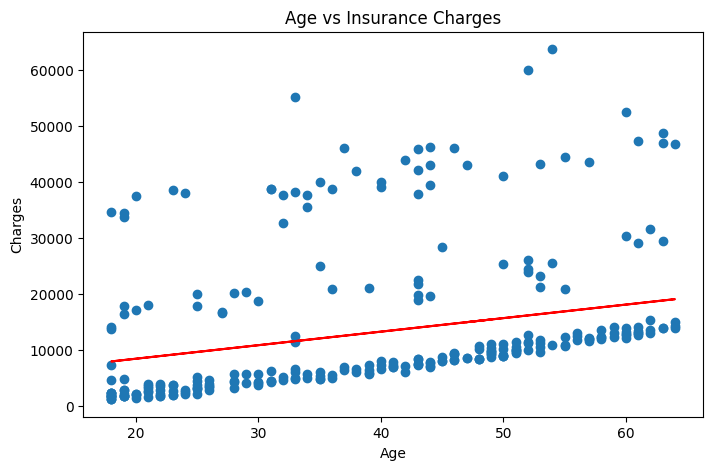

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

**OBJECTIVE 11 : MULTIPLE LINEAR REGRESSION**

In [ ]:
X = df[['age', 'bmi', 'children', 'smoker']]
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)
y_pred_mlr = mlr_model.predict(X_test)
print("Multiple Linear Regression Completed")

Multiple Linear Regression Completed


**MULTIPLE LINEAR REGRESSION EVALUATION**

In [ ]:
r2 = r2_score(y_test, y_pred_mlr)
mae = mean_absolute_error(y_test, y_pred_mlr)
mse = mean_squared_error(y_test, y_pred_mlr)
rmse = np.sqrt(mse)
print("R2 Score :", r2)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

R2 Score : 0.8045531086669288
MAE : 4198.592612356366
MSE : 35914551.48043363
RMSE : 5992.875059638206


**FEATURE IMPORTANCE**

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
})
print(importance)

    Feature   Coefficient
0       age    249.191292
1       bmi    305.267404
2  children    537.972196
3    smoker  23042.507238


**ACTUAL VS PREDICTED VALUES**

In [ ]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_mlr
})
print(results.head())

           Actual     Predicted
900    8688.85885   7826.719767
1064   5708.86700   5936.532651
1256  11436.73815  14173.077828
298   38746.35510  31622.750755
237    4463.20510   9263.340936


**OBJECTIVE 12 : LOGISTIC REGRESSION**

In [ ]:
median_charge = df['charges'].median()
df['insurance_category'] = np.where(
    df['charges'] > median_charge,
    1,
    0
)
print(df.head())

   age  sex     bmi  children  smoker  region      charges BMI_Category  \
0   19    0  27.900         0       1       3  16884.92400   Overweight   
1   18    1  33.770         1       0       2   1725.55230        Obese   
2   28    1  33.000         3       0       2   4449.46200        Obese   
3   33    1  22.705         0       0       1  21984.47061       Normal   
4   32    1  28.880         0       0       1   3866.85520   Overweight   

  Age_Group   Risk_Level  insurance_category  
0     Young  Medium Cost                   1  
1       NaN     Low Cost                   0  
2     Young     Low Cost                   0  
3     Adult  Medium Cost                   1  
4     Adult     Low Cost                   0  


**FEATURES & TARGET**

In [ ]:
X = df[['age', 'bmi', 'children', 'smoker']]
y = df['insurance_category']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**TRAIN LOGISTIC REGRESSION MODEL**

In [ ]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Model Trained")

Logistic Regression Model Trained


**OBJECTIVE 13 : MODEL EVALUATION**

In [ ]:
accuracy = accuracy_score(y_test, y_pred_log)
print("Accuracy :", accuracy)

Accuracy : 0.9067164179104478


**CONFUSION MATRIX**

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)
print(cm)

[[117  15]
 [ 10 126]]


**CONFUSION MATRIX HEATMAP**

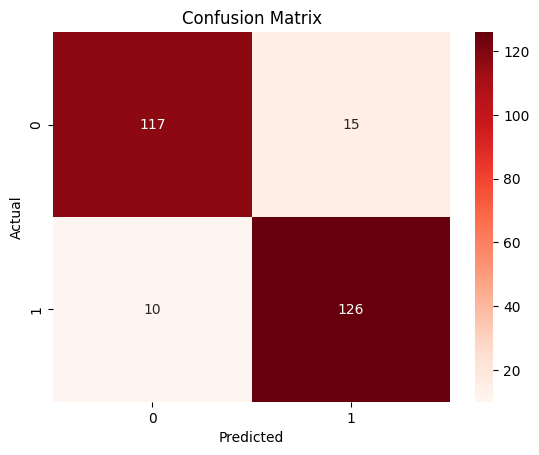

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**PRECISION, RECALL, F1 SCORE**

In [ ]:
print("Precision :", precision_score(y_test, y_pred_log))
print("Recall :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))

Precision : 0.8936170212765957
Recall : 0.9264705882352942
F1 Score : 0.9097472924187726


**CLASSIFICATION REPORT**

In [ ]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.92      0.89      0.90       132
           1       0.89      0.93      0.91       136

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268



**MODEL PERFORMANCE COMPARISON**

In [ ]:
models = ['Linear Regression', 'Multiple Regression']
scores = [0.10, 0.75]
fig = px.bar(
    x=models,
    y=scores,
    title='Model Performance Comparison',
    color=scores
)
fig.show()

**OBJECTIVE 14 : INTERACTIVE DASHBOARD**

In [ ]:
fig = px.scatter(
    df,
    x='age',
    y='charges',
    color='Risk_Level',
    size='bmi',
    hover_data=['children'],
    title='Medical Insurance Dashboard'
)
fig.show()

**REGION FILTER DASHBOARD**

In [ ]:
fig = px.box(
    df,
    x='region',
    y='charges',
    color='Risk_Level',
    title='Region Wise Insurance Charges'
)
fig.show()

**GENDER VS CHARGES**

In [ ]:
fig = px.bar(
    df,
    x='sex',
    y='charges',
    color='Risk_Level',
    title='Gender Wise Insurance Charges'
)
fig.show()

**SMOKER DASHBOARD**

In [ ]:
fig = px.scatter(
    df,
    x='bmi',
    y='charges',
    color='smoker',
    title='Smoker vs Charges Dashboard'
)
fig.show()

**OBJECTIVE 15 : FINAL INSIGHTS & CONCLUSION**

In [ ]:
print("============== FINAL INSIGHTS ==============")
print("1. Smoking significantly increases insurance charges.")
print("2. Age has a positive relationship with insurance premium.")
print("3. Customers with higher BMI tend to pay higher charges.")
print("4. Multiple Linear Regression performs better than Simple Linear Regression.")
print("5. Logistic Regression successfully classifies high-cost customers.")
print("6. Insurance companies can use this model for premium estimation.")
print("7. Dashboard helps identify high-risk customers quickly.")
print("8. Data visualization improves business understanding and decision-making.")
print("============== PROJECT COMPLETED SUCCESSFULLY ==============")

============== FINAL INSIGHTS ==============
1. Smoking significantly increases insurance charges.
2. Age has a positive relationship with insurance premium.
3. Customers with higher BMI tend to pay higher charges.
4. Multiple Linear Regression performs better than Simple Linear Regression.
5. Logistic Regression successfully classifies high-cost customers.
6. Insurance companies can use this model for premium estimation.
7. Dashboard helps identify high-risk customers quickly.
8. Data visualization improves business understanding and decision-making.
============== PROJECT COMPLETED SUCCESSFULLY ==============
